# 1. 라이브러리 및 데이터

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [3]:
!wget -O movie_data.zip "https://bit.ly/3zdjdTM"

# 압축 해제
import zipfile
import os
import pandas as pd

with zipfile.ZipFile('movie_data.zip', 'r') as existing_zip:
    existing_zip.extractall('movie_data')

file_list = os.listdir('movie_data')

train_name = [f for f in file_list if 'train' in f][0]
test_name = [f for f in file_list if 'test' in f][0]
sub_name = [f for f in file_list if 'sub' in f or 'submission' in f][0]

train_path = os.path.join('movie_data', train_name)
test_path = os.path.join('movie_data', test_name)
sub_path = os.path.join('movie_data', sub_name)

# 한글 깨짐 및 인코딩 에러 방지 예외처리
try:
    train = pd.read_csv(train_path, encoding='cp949')
    test = pd.read_csv(test_path, encoding='cp949')
    smpl_sub = pd.read_csv(sub_path, encoding='cp949')
except Exception:
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    smpl_sub = pd.read_csv(sub_path)

--2026-06-14 10:40:32--  https://bit.ly/3zdjdTM
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://drive.google.com/uc?export=download&id=1aNmGyhDrW9tTMhy2GFZMEFkQlyCZNYGv [following]
--2026-06-14 10:40:32--  https://drive.google.com/uc?export=download&id=1aNmGyhDrW9tTMhy2GFZMEFkQlyCZNYGv
Resolving drive.google.com (drive.google.com)... 192.178.163.113, 192.178.163.101, 192.178.163.100, ...
Connecting to drive.google.com (drive.google.com)|192.178.163.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1aNmGyhDrW9tTMhy2GFZMEFkQlyCZNYGv&export=download [following]
--2026-06-14 10:40:32--  https://drive.usercontent.google.com/download?id=1aNmGyhDrW9tTMhy2GFZMEFkQlyCZNYGv&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)...

In [4]:
train.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [5]:
test.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor
0,용서는 없다,시네마서비스,느와르,2010-01-07,125,청소년 관람불가,김형준,3.005290e+05,2,304,3
1,아빠가 여자를 좋아해,(주)쇼박스,멜로/로맨스,2010-01-14,113,12세 관람가,이광재,3.427002e+05,4,275,3
2,하모니,CJ 엔터테인먼트,드라마,2010-01-28,115,12세 관람가,강대규,4.206611e+06,3,419,7
3,의형제,(주)쇼박스,액션,2010-02-04,116,15세 관람가,장훈,6.913420e+05,2,408,2
4,평행 이론,CJ 엔터테인먼트,공포,2010-02-18,110,15세 관람가,권호영,3.173800e+04,1,380,1


In [6]:
print(f"  Train shape : {train.shape}")
print(f"  Test  shape : {test.shape}")
print(f"  Target skewness : {train['box_off_num'].skew():.3f}")

  Train shape : (600, 12)
  Test  shape : (243, 11)
  Target skewness : 4.332


# 2. 데이터 전처리 및 학습, 검증 함수

## 2-1. 피처 엔지니어링

In [7]:
def feature_engineering(df, train_ref):
    df = df.copy()

    df['release_time'] = pd.to_datetime(df['release_time'])
    df['release_year'] = df['release_time'].dt.year
    df['release_month'] = df['release_time'].dt.month
    df['release_weekday'] = df['release_time'].dt.weekday
    df['release_quarter'] = df['release_time'].dt.quarter
    df['is_peak_season'] = df['release_month'].isin([1, 7, 8, 12]).astype(int)
    df.drop(columns=['release_time'], inplace=True)

    df['is_new_director'] = (df['dir_prev_num'] == 0).astype(int)
    df['dir_prev_bfnum'] = df['dir_prev_bfnum'].fillna(0)
    df['log_dir_prev_bfnum'] = np.log1p(df['dir_prev_bfnum'])
    df['log_num_staff'] = np.log1p(df['num_staff'])

    dist_freq = train_ref['distributor'].value_counts()
    df['distributor_freq'] = df['distributor'].map(dist_freq).fillna(0)

    return df

## 2-2. 범주형 인코딩

In [8]:
def encode_categories(train_df, test_df, cat_cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for col in cat_cols:
        le = LabelEncoder()
        le.fit(pd.concat([train_df[col], test_df[col]], axis=0).astype(str))
        train_df[col] = le.transform(train_df[col].astype(str))
        test_df[col]  = le.transform(test_df[col].astype(str))

    return train_df, test_df

## 2-3. 타깃 로그 변환, train/val 분리

In [9]:
def prepare_data(train_df, feature_cols, test_size=0.2, random_state=42):
    X = train_df[feature_cols]
    y = train_df['box_off_num']
    y_log = np.log1p(y)

    print(f"Target skewness : {y_log.skew():.4f}")

    X_train, X_val, y_train_log, y_val_log = train_test_split(
        X, y_log, test_size=test_size, random_state=random_state
    )
    y_val_origin = np.expm1(y_val_log)

    return X, y_log, X_train, X_val, y_train_log, y_val_log, y_val_origin

## 2-4. 선형 모델용 스케일링

In [10]:
def scale_data(X_train, X_val):
    scaler = StandardScaler()
    return scaler, scaler.fit_transform(X_train), scaler.transform(X_val)

## 2-5. 모델 학습 및 검증

In [11]:
linear_models = ("Ridge", "Lasso")

def train_and_evaluate(models, X_train, X_val, y_train_log, y_val_log,
                       X_train_sc, X_val_sc):
    y_val_origin = np.expm1(y_val_log)
    results = {}

    for name, model in models.items():
        if name in linear_models:
            model.fit(X_train_sc, y_train_log)
            y_pred_log = model.predict(X_val_sc)
        else:
            model.fit(X_train, y_train_log)
            y_pred_log = model.predict(X_val)

        y_pred_origin = np.expm1(y_pred_log)
        rmse = np.sqrt(mean_squared_error(y_val_origin, y_pred_origin))
        r2 = r2_score(y_val_log, y_pred_log)

        results[name] = {"model": model, "RMSE": rmse, "R2": r2}
        print(f"Model {name} - RMSE: {rmse:.0f}, R2: {r2:.4f}")

    return results

## 2-6. 피처 중요도 시각화

In [12]:
def plot_feature_importance(model, model_name, feature_cols, top_n=15):
    if hasattr(model, 'feature_importances_'):
        fi = pd.Series(model.feature_importances_, index=feature_cols)
        xlabel = "Feature Importance"
    elif hasattr(model, 'coef_'):
        fi = pd.Series(model.coef_, index=feature_cols)
        xlabel = "Coefficient"
    else:
        return

    fi_sorted = fi.sort_values(ascending=False)[:top_n]
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.barplot(x=fi_sorted.values, y=fi_sorted.index, ax=ax)
    ax.set_title(f"Feature Importance of {model_name} (Top {top_n})")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Feature")
    plt.show()

## 2-7. 예측 및 결과 저장

# 3. 모델 학습 실행

## 3-1. 데이터 전처리

In [14]:
# 피처 엔지니어링
train_fe = feature_engineering(train, train_ref = train)
test_fe  = feature_engineering(test, train_ref = train)

In [15]:
# 필요없는 컬럼 드랍
train_fe.drop(columns=['title','director','distributor'], inplace=True)
test_fe.drop(columns=['title','director','distributor'], inplace=True)

In [16]:
# 범주형 인코딩
cat_cols = ['genre', 'screening_rat']
train_fe, test_fe = encode_categories(train_fe, test_fe, cat_cols)

feature_cols = [c for c in train_fe.columns if c != 'box_off_num']
print(feature_cols)

['genre', 'time', 'screening_rat', 'dir_prev_bfnum', 'dir_prev_num', 'num_staff', 'num_actor', 'release_year', 'release_month', 'release_weekday', 'release_quarter', 'is_peak_season', 'is_new_director', 'log_dir_prev_bfnum', 'log_num_staff', 'distributor_freq']


In [17]:
# 타깃 변환 & 데이터 분리
X, y_log, X_train, X_val, y_train_log, y_val_log, y_val_orig = prepare_data(
    train_fe, feature_cols)

Target skewness : 0.1338


In [18]:
# 스케일링
scaler, X_train_sc, X_val_sc = scale_data(X_train, X_val)

## 3-2. 모델 학습 및 검증

1) XGBoost

In [19]:
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(X, y_log)

pred_log = model_xgb.predict(test_fe[feature_cols])

pred = np.expm1(pred_log)

pred_real = np.clip(pred, 0, None)

smpl_sub['box_off_num'] = pred_real
smpl_sub.to_csv('submission_xgb_final.csv', index=False)

print("XGBoost 모델 학습 및 예측 완료. 파일이 생성되었습니다.")

XGBoost 모델 학습 및 예측 완료. 파일이 생성되었습니다.


2) 앙상블

In [21]:
# 모델 정의 및 앙상블 가중치 설정
models_ensemble = {
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
    "GBM": GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
}
weights = {"LightGBM": 0.4, "GBM": 0.2, "XGBoost": 0.4}

# 교차검증 및 테스트 예측값 초기화
oof_preds = {name: np.zeros(len(X)) for name in models_ensemble}
test_preds = {name: np.zeros(len(test_fe)) for name in models_ensemble}

# 5-Fold 학습 및 예측
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_test = test_fe[feature_cols]

for trn_idx, val_idx in kf.split(X):
    X_tr, y_tr = X.iloc[trn_idx], y_log.iloc[trn_idx]
    X_val = X.iloc[val_idx]

    for name, model in models_ensemble.items():
        model.fit(X_tr, y_tr)
        oof_preds[name][val_idx] = model.predict(X_val)
        test_preds[name] += model.predict(X_test) / kf.n_splits

# 모델별 성능 평가 및 가중 평균 앙상블
y_true = np.expm1(y_log)
ensemble_oof = np.zeros(len(X))  # 로그 스케일
final_preds_log = np.zeros(len(X_test))

print("모델별 RMSE")
for name in models_ensemble:
    rmse = np.sqrt(mean_squared_error(y_true, np.expm1(oof_preds[name])))
    print(f"{name}: {rmse:,.0f}")

    ensemble_oof += oof_preds[name] * weights[name]
    final_preds_log += test_preds[name] * weights[name]

print(f"\n최종 앙상블 RMSE : {np.sqrt(mean_squared_error(y_true, np.expm1(ensemble_oof))):,.0f}")

모델별 RMSE
LightGBM: 1,452,057
GBM: 1,526,560
XGBoost: 1,577,976

최종 앙상블 RMSE : 1,490,820


In [22]:
# 제출 파일 생성 및 저장
final_preds = np.where(np.expm1(final_preds_log) < 0, 0, np.expm1(final_preds_log)).astype(int)

submission = pd.DataFrame({
    'title': test['title'],
    'box_off_num': final_preds
})
submission.to_csv('submission_ensembel.csv', index=False)
print("submission_ensemble.csv 파일 생성")

submission_ensemble.csv 파일 생성


3) CatBoost

In [23]:
# 1. 필수 라이브러리 마운트 및 임포트
!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error, r2_score

# 2. 교차 검증 및 학습 함수 정의
def train_and_evaluate_catboost(X_train_full, y_train_full, X_test_full, cat_features):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    oof_preds = np.zeros(len(X_train_full))
    test_preds = np.zeros(len(X_test_full))
    fold_rmse_list = []
    fold_r2_list = []

    # 5-Fold 교차 검증 루프 시작
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full, y_train_full)):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        # CatBoostRegressor 모델 설정 (하이퍼파라미터 정의)
        model = CatBoostRegressor(
            iterations=1500,
            learning_rate=0.05,
            depth=6,
            eval_metric='RMSE',
            random_state=42,
            verbose=0
        )

        # 모델 학습 (Early Stopping 적용)
        model.fit(
            X_tr, y_tr,
            eval_set=(X_va, y_va),
            cat_features=cat_features,
            early_stopping_rounds=100,
            verbose=False
        )

        # 검증 데이터 예측 및 실제 관객 수 단위 복원(expm1)
        val_pred_log = model.predict(X_va)
        oof_preds[val_idx] = np.expm1(val_pred_log)

        # 실제 관객수 기준 RMSE 및 로그 기준 R2 계산
        fold_rmse = root_mean_squared_error(np.expm1(y_va), oof_preds[val_idx])
        fold_r2 = r2_score(y_va, val_pred_log)

        fold_rmse_list.append(fold_rmse)
        fold_r2_list.append(fold_r2)

        print(f"Fold {fold+1} - RMSE: {fold_rmse:.0f}, R2: {fold_r2:.4f}")

        # 테스트 데이터 예측값 평균 누적 (5개 폴드 평균)
        test_preds += np.expm1(model.predict(X_test_full)) / 5

    print(f"\nModel CatBoost - Mean RMSE: {np.mean(fold_rmse_list):.0f}, Mean R2: {np.mean(fold_r2_list):.4f}")

    return model, test_preds

# 3. 특성 중요도(Feature Importance) 시각화 함수 정의
def plot_feature_importance(model, model_name, feature_cols, top_n=15):
    if hasattr(model, 'get_feature_importance'):
        fi = pd.Series(model.get_feature_importance(), index=feature_cols)
        xlabel = "Feature Importance"
    elif hasattr(model, 'feature_importances_'):
        fi = pd.Series(model.feature_importances_, index=feature_cols)
        xlabel = "Feature Importance"
    elif hasattr(model, 'coef_'):
        fi = pd.Series(model.coef_, index=feature_cols)
        xlabel = "Coefficient"
    else:
        return

    fi_sorted = fi.sort_values(ascending=False)[:top_n]
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.barplot(x=fi_sorted.values, y=fi_sorted.index, ax=ax)
    ax.set_title(f"Feature Importance of {model_name} (Top {top_n})")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Feature")
    plt.show()

# 4. 예측 결과 저장 함수 정의
def predict_and_save(test_preds, submission_df, save_path=""):
    pred_origin = np.clip(test_preds, a_min=0, a_max=None).astype(int)
    submission_df['box_off_num'] = pred_origin

    full_path = save_path + "submission_cat.csv"
    submission_df.to_csv(full_path, index=False)

    print("\n[제출 파일 상위 5개 데이터 확인]")
    print(submission_df.head())

    return submission_df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


Fold 1 - RMSE: 1077521, R2: 0.6816
Fold 2 - RMSE: 974074, R2: 0.6011
Fold 3 - RMSE: 1314592, R2: 0.7215
Fold 4 - RMSE: 1772892, R2: 0.6684
Fold 5 - RMSE: 2010897, R2: 0.7177

Model CatBoost - Mean RMSE: 1429995, Mean R2: 0.6780
최적 모델 : CatBoost


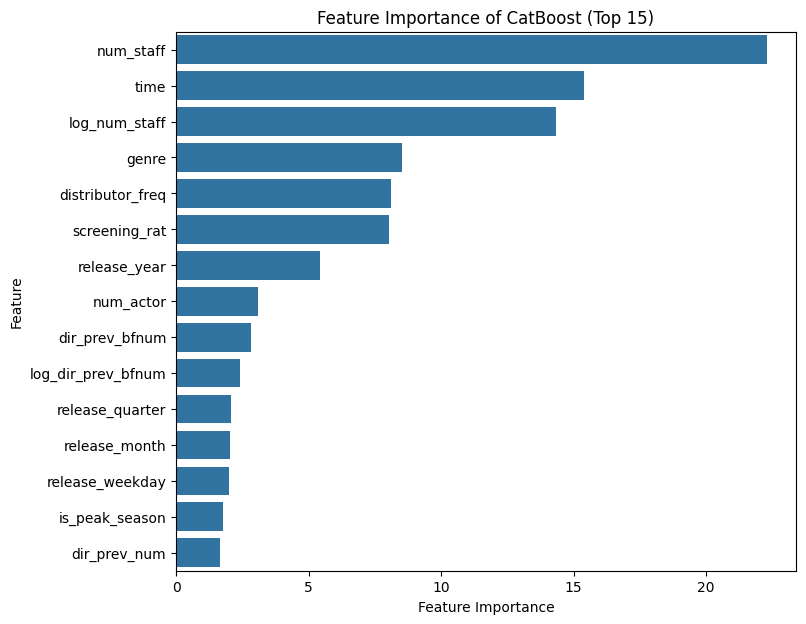

In [25]:
import pandas as pd

# 5-Fold 교차 검증 기반 모델 학습 진행
best_model, test_predictions = train_and_evaluate_catboost(
    X, y_log, test_fe[feature_cols], cat_cols
)

best_name = "CatBoost"
print(f"최적 모델 : {best_name}")

# 피처 중요도 시각화 출력
plot_feature_importance(best_model, best_name, feature_cols, top_n=15)

In [26]:
# 예측 결과 저장 함수 호출
predict_and_save(
    test_preds = test_predictions,
    submission_df = submission,
    save_path = ""
)

# 구글 코랩 파일 다운로드 파일 생성
from google.colab import files
files.download('submission_cat.csv')


[제출 파일 상위 5개 데이터 확인]
         title  box_off_num
0       용서는 없다       953768
1  아빠가 여자를 좋아해       553929
2          하모니       562732
3          의형제      1055846
4        평행 이론       642011


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

4) LightGBM

In [29]:
# 피처 엔지니어링
train_fe = feature_engineering(train, train_ref = train)
test_fe  = feature_engineering(test, train_ref = train)

# 필요없는 컬럼 드랍

train_fe.drop(columns=['title','director','distributor'], inplace=True)

test_fe.drop(columns=['title','director','distributor'], inplace=True)


# 범주형 인코딩

cat_cols = ['genre', 'screening_rat']

train_fe, test_fe = encode_categories(train_fe, test_fe, cat_cols)

feature_cols = [c for c in train_fe.columns if c != 'box_off_num']

print(feature_cols)

# 타깃 변환 & 데이터 분리

X, y_log, X_train, X_val, y_train_log, y_val_log, y_val_orig = prepare_data(

    train_fe, feature_cols)

# 스케일링

scaler, X_train_sc, X_val_sc = scale_data(X_train, X_val)

['genre', 'time', 'screening_rat', 'dir_prev_bfnum', 'dir_prev_num', 'num_staff', 'num_actor', 'release_year', 'release_month', 'release_weekday', 'release_quarter', 'is_peak_season', 'is_new_director', 'log_dir_prev_bfnum', 'log_num_staff', 'distributor_freq']
Target skewness : 0.1338


In [30]:
models = {
    "Ridge": Ridge(alpha=10.0),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=10,
                                          min_samples_leaf=3, random_state=42, n_jobs=-1),
    "GBM": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=4, subsample=0.8, random_state=42),
    "XGBoost":  XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                             subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1),
}

In [31]:
# 학습 및 검증
results = train_and_evaluate(models, X_train, X_val, y_train_log, y_val_log,
                             X_train_sc, X_val_sc)

Model Ridge - RMSE: 1611690, R2: 0.6052
Model Lasso - RMSE: 1603160, R2: 0.6044
Model RandomForest - RMSE: 1166401, R2: 0.6741
Model GBM - RMSE: 1204880, R2: 0.6669
Model XGBoost - RMSE: 1252490, R2: 0.6709
Model LightGBM - RMSE: 1120548, R2: 0.6739


In [32]:
# 최적 모델
best_name = min(results, key=lambda k: results[k]["RMSE"])
best_result = results[best_name]
best_model  = best_result["model"]
print(f"최적 모델 : {best_name}, RMSE : {best_result['RMSE']:,.0f}")

최적 모델 : LightGBM, RMSE : 1,120,548


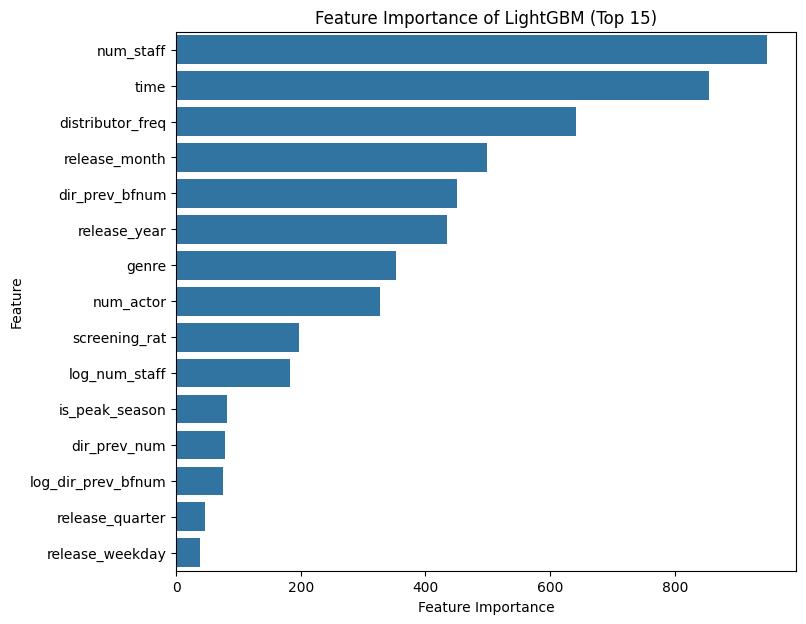

In [33]:
# 피처 중요도 시각화
plot_feature_importance(best_model, best_name, feature_cols, top_n=15)

In [41]:
def predict_and_save(model, model_name, X, y_log, X_test,
                     test_titles, scaler=None,
                     save_path="submission_final"):
    if model_name in linear_models:
        X_sc = scaler.fit_transform(X)
        model.fit(X_sc, y_log)
        pred_log = model.predict(scaler.transform(X_test))
    else:
        model.fit(X, y_log)
        pred_log = model.predict(X_test)

    pred_origin = np.expm1(pred_log).clip(min=0).astype(int)
    submission = pd.DataFrame({"title": test_titles, "box_off_num": pred_origin})
    submission.to_csv(save_path + ".csv", index=False)

    submission.head()
    return

In [42]:
predict_and_save(
    best_model, best_name, X, y_log,
    X_test=test_fe[feature_cols],
    test_titles=test["title"],
    scaler=scaler)